# Linear Programming: Simplex Method (จำลอง + เปรียบเทียบ)

Notebook นี้ให้คุณ:
1. รัน **Simplex Method** แบบ manual ทีละ tableau (เห็นทุก entering/leaving/pivot)
2. เปรียบเทียบผลกับ **scipy.optimize.linprog** (คำตอบต้องตรงกัน)
3. ดู **Graphical Method** (feasible region + corner points) สำหรับปัญหา 2 ตัวแปร
4. ลองแก้ไขโจทย์ของคุณเองได้ที่ท้ายไฟล์

โจทย์ตั้งต้น (จากเลคเชอร์):

Maximize Z = 3x1 + 5x2

subject to:
- x1 ≤ 4
- 2x2 ≤ 12
- 3x1 + 2x2 ≤ 18
- x1, x2 ≥ 0


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog

pd.set_option('display.precision', 3)


## 1. Manual Simplex Method (ดูทุก tableau)

In [2]:
def simplex_maximize(c, A, b, var_names=None, verbose=True):
    """
    แก้ปัญหา: Maximize c^T x  subject to A x <= b, x >= 0
    (ใช้ได้กับ constraint แบบ <= เท่านั้น, ไม่รองรับ >= หรือ = ในฟังก์ชันนี้)

    c : list สัมประสิทธิ์ objective (เช่น [3, 5])
    A : list of list สัมประสิทธิ์ constraint (เช่น [[1,0],[0,2],[3,2]])
    b : list ค่า RHS (เช่น [4, 12, 18])

    คืนค่า: dict ของ x*, Z*, และ tableau ทุกขั้นตอน (list of DataFrame)
    """
    c = np.array(c, dtype=float)
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)
    n_vars = len(c)
    n_cons = len(b)

    if var_names is None:
        var_names = [f"x{i+1}" for i in range(n_vars)]
    slack_names = [f"S{i+1}" for i in range(n_cons)]
    all_names = var_names + slack_names + ["RHS"]

    # สร้าง tableau เริ่มต้น: [A | I | b] แถวบน, [-c | 0 | 0] แถว Z
    tableau = np.zeros((n_cons + 1, n_vars + n_cons + 1))
    tableau[:n_cons, :n_vars] = A
    tableau[:n_cons, n_vars:n_vars + n_cons] = np.eye(n_cons)
    tableau[:n_cons, -1] = b
    tableau[-1, :n_vars] = -c

    basic = slack_names.copy()
    history = []
    iteration = 0

    def snapshot(note):
        df = pd.DataFrame(tableau, columns=all_names,
                           index=basic + ["Z"])
        history.append((note, df.copy()))
        if verbose:
            print(f"--- {note} ---")
            print(df.round(3))
            print()

    snapshot(f"Iteration {iteration}: initial tableau")

    while True:
        z_row = tableau[-1, :-1]
        if np.all(z_row >= -1e-9):
            break  # ไม่มีค่าติดลบแล้ว -> optimal

        entering = np.argmin(z_row)  # ค่าลบมากที่สุด

        col = tableau[:n_cons, entering]
        rhs = tableau[:n_cons, -1]
        ratios = np.where(col > 1e-9, rhs / np.where(col > 1e-9, col, 1), np.inf)

        if np.all(ratios == np.inf):
            raise ValueError("Unbounded solution")

        leaving = np.argmin(ratios)
        pivot_val = tableau[leaving, entering]

        iteration += 1
        entering_name = all_names[entering]
        leaving_name = basic[leaving]

        # ทำ pivot: normalize แถว leaving แล้วลบออกจากแถวอื่นทั้งหมด
        tableau[leaving, :] /= pivot_val
        for r in range(len(tableau)):
            if r != leaving:
                tableau[r, :] -= tableau[r, entering] * tableau[leaving, :]

        basic[leaving] = entering_name
        snapshot(f"Iteration {iteration}: {entering_name} เข้าแทน {leaving_name}")

    # อ่านคำตอบ
    solution = {name: 0.0 for name in var_names}
    for i, name in enumerate(basic):
        if name in solution:
            solution[name] = tableau[i, -1]
    z_value = tableau[-1, -1]

    return {"x": solution, "Z": z_value, "history": history}


In [3]:
# โจทย์ตั้งต้น: Maximize Z = 3x1 + 5x2
c = [3, 5]
A = [[1, 0],
     [0, 2],
     [3, 2]]
b = [4, 12, 18]

result = simplex_maximize(c, A, b, var_names=["x1", "x2"])

print("คำตอบ:", result["x"])
print("Z max =", result["Z"])


--- Iteration 0: initial tableau ---
     x1   x2   S1   S2   S3   RHS
S1  1.0  0.0  1.0  0.0  0.0   4.0
S2  0.0  2.0  0.0  1.0  0.0  12.0
S3  3.0  2.0  0.0  0.0  1.0  18.0
Z  -3.0 -5.0  0.0  0.0  0.0   0.0

--- Iteration 1: x2 เข้าแทน S2 ---
     x1   x2   S1   S2   S3   RHS
S1  1.0  0.0  1.0  0.0  0.0   4.0
x2  0.0  1.0  0.0  0.5  0.0   6.0
S3  3.0  0.0  0.0 -1.0  1.0   6.0
Z  -3.0  0.0  0.0  2.5  0.0  30.0

--- Iteration 2: x1 เข้าแทน S3 ---
     x1   x2   S1     S2     S3   RHS
S1  0.0  0.0  1.0  0.333 -0.333   2.0
x2  0.0  1.0  0.0  0.500  0.000   6.0
x1  1.0  0.0  0.0 -0.333  0.333   2.0
Z   0.0  0.0  0.0  1.500  1.000  36.0

คำตอบ: {'x1': np.float64(2.0), 'x2': np.float64(6.0)}
Z max = 36.0


## 2. เปรียบเทียบกับ scipy.optimize.linprog

`linprog` ทำ **minimize** เป็นค่าเริ่มต้น ดังนั้นถ้าจะ maximize ต้องใส่ `-c`

In [4]:
# scipy ต้องการ minimize -> ใส่ -c เพื่อ maximize
res = linprog(c=[-ci for ci in c], A_ub=A, b_ub=b, bounds=[(0, None)] * len(c), method="highs")

print("scipy solution:", res.x)
print("scipy Z max   :", -res.fun)

print()
print("manual solution:", list(result["x"].values()))
print("manual Z max   :", result["Z"])

assert abs(-res.fun - result["Z"]) < 1e-6, "ผลลัพธ์ไม่ตรงกัน ตรวจสอบโจทย์อีกครั้ง"
print("\nตรงกัน! (matched)")


scipy solution: [2. 6.]
scipy Z max   : 36.0

manual solution: [np.float64(2.0), np.float64(6.0)]
manual Z max   : 36.0

ตรงกัน! (matched)


## 3. Graphical Method (สำหรับปัญหา 2 ตัวแปร)

วาด feasible region, เส้น constraint, และจุดมุมที่ optimal

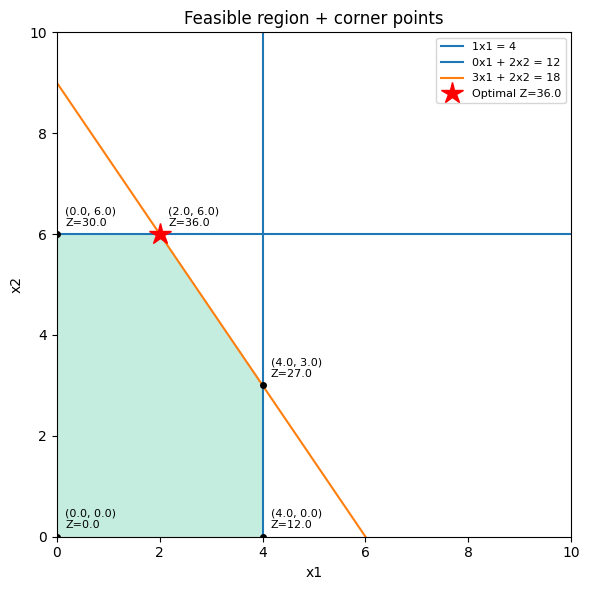

จุดที่ดีที่สุดจากกราฟ: [2. 6.] Z = 36.0


In [5]:
def plot_graphical(c, A, b, xlim=15, ylim=15, resolution=400):
    """วาด feasible region และหา corner point ที่ดีที่สุด (สำหรับ 2 ตัวแปรเท่านั้น)"""
    assert len(c) == 2, "ใช้ได้กับ 2 ตัวแปรเท่านั้น"

    x = np.linspace(0, xlim, resolution)
    y = np.linspace(0, ylim, resolution)
    X, Y = np.meshgrid(x, y)

    feasible = np.ones_like(X, dtype=bool)
    for (a1, a2), bi in zip(A, b):
        feasible &= (a1 * X + a2 * Y <= bi + 1e-9)
    feasible &= (X >= 0) & (Y >= 0)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.contourf(X, Y, feasible.astype(int), levels=[0.5, 1], colors=["#9FE1CB"], alpha=0.6)

    for (a1, a2), bi in zip(A, b):
        if a2 != 0:
            yy = (bi - a1 * x) / a2
            ax.plot(x, yy, label=f"{a1}x1 + {a2}x2 = {bi}")
        else:
            ax.axvline(bi / a1, label=f"{a1}x1 = {bi}")

    # หา corner points จากจุดตัดของทุกคู่เส้น (รวมแกน x=0, y=0)
    lines = list(A) + [[1, 0], [0, 1]]
    rhs = list(b) + [0, 0]
    corners = []
    for i in range(len(lines)):
        for j in range(i + 1, len(lines)):
            Amat = np.array([lines[i], lines[j]])
            bvec = np.array([rhs[i], rhs[j]])
            if abs(np.linalg.det(Amat)) < 1e-9:
                continue
            pt = np.linalg.solve(Amat, bvec)
            if pt[0] >= -1e-6 and pt[1] >= -1e-6:
                if all(a1 * pt[0] + a2 * pt[1] <= bi + 1e-6 for (a1, a2), bi in zip(A, b)):
                    corners.append(pt)

    corners = np.unique(np.round(corners, 6), axis=0)
    z_vals = [c[0] * p[0] + c[1] * p[1] for p in corners]
    best_idx = int(np.argmax(z_vals))

    for p, z in zip(corners, z_vals):
        ax.plot(*p, "ko", markersize=4)
        ax.annotate(f"({p[0]:.1f}, {p[1]:.1f})\nZ={z:.1f}", p, textcoords="offset points", xytext=(6, 6), fontsize=8)

    best = corners[best_idx]
    ax.plot(*best, "r*", markersize=16, label=f"Optimal Z={z_vals[best_idx]:.1f}")

    ax.set_xlim(0, xlim)
    ax.set_ylim(0, ylim)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.legend(fontsize=8, loc="upper right")
    ax.set_title("Feasible region + corner points")
    plt.tight_layout()
    plt.show()

    return best, z_vals[best_idx]

best_point, best_z = plot_graphical(c, A, b, xlim=10, ylim=10)
print("จุดที่ดีที่สุดจากกราฟ:", best_point, "Z =", best_z)


## 4. ลองโจทย์ของคุณเอง

แก้ค่า `c`, `A`, `b` ด้านล่าง แล้วรันใหม่ทั้ง 3 วิธี (manual simplex, scipy, graphical) เพื่อเปรียบเทียบ

ตัวอย่าง: โจทย์จากสไลด์ "Try to do"

Maximize Z = 3x1 + 2x2
- x1 + x2 ≤ 4
- 2x1 + x2 ≤ 5


--- Iteration 0: initial tableau ---
     x1   x2   S1   S2  RHS
S1  1.0  1.0  1.0  0.0  4.0
S2  2.0  1.0  0.0  1.0  5.0
Z  -3.0 -2.0  0.0  0.0  0.0

--- Iteration 1: x1 เข้าแทน S2 ---
     x1   x2   S1   S2  RHS
S1  0.0  0.5  1.0 -0.5  1.5
x1  1.0  0.5  0.0  0.5  2.5
Z   0.0 -0.5  0.0  1.5  7.5

--- Iteration 2: x2 เข้าแทน S1 ---
     x1   x2   S1   S2  RHS
x2  0.0  1.0  2.0 -1.0  3.0
x1  1.0  0.0 -1.0  1.0  1.0
Z   0.0  0.0  1.0  1.0  9.0

Manual simplex: {'x1': np.float64(1.0), 'x2': np.float64(3.0)} Z = 9.0
scipy linprog : [1. 3.] Z = 9.0


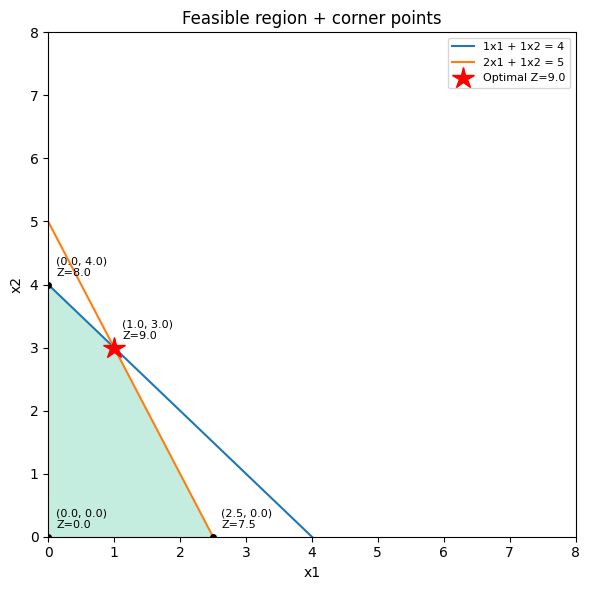

In [6]:
# ==== แก้ตรงนี้เพื่อลองโจทย์ใหม่ ====
c_new = [3, 2]
A_new = [[1, 1],
         [2, 1]]
b_new = [4, 5]
# ===================================

result_new = simplex_maximize(c_new, A_new, b_new, var_names=["x1", "x2"])
print("Manual simplex:", result_new["x"], "Z =", result_new["Z"])

res_new = linprog(c=[-ci for ci in c_new], A_ub=A_new, b_ub=b_new,
                   bounds=[(0, None)] * len(c_new), method="highs")
print("scipy linprog :", res_new.x, "Z =", -res_new.fun)

if len(c_new) == 2:
    plot_graphical(c_new, A_new, b_new, xlim=8, ylim=8)
